<a href="https://colab.research.google.com/github/sakshiitripathii/applyguard-ai/blob/main/Sakshi_Tripathi_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HOUSE PRICE PREDICTION PROJECT

Dataset shape: (20640, 9)

First five rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 

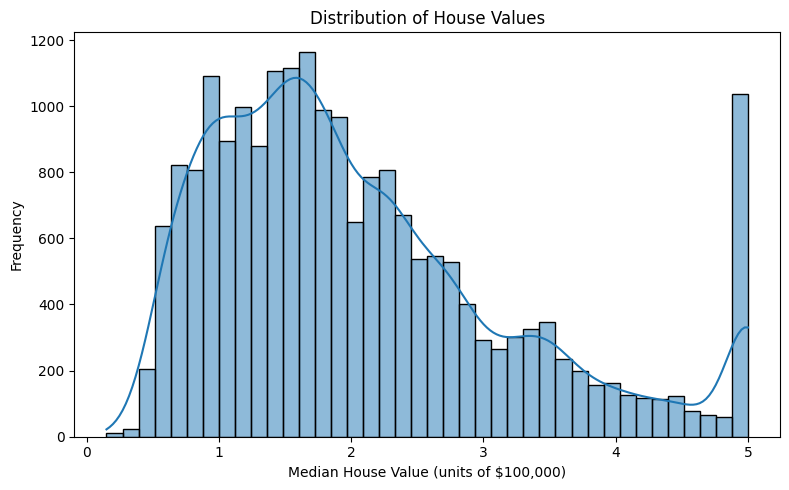

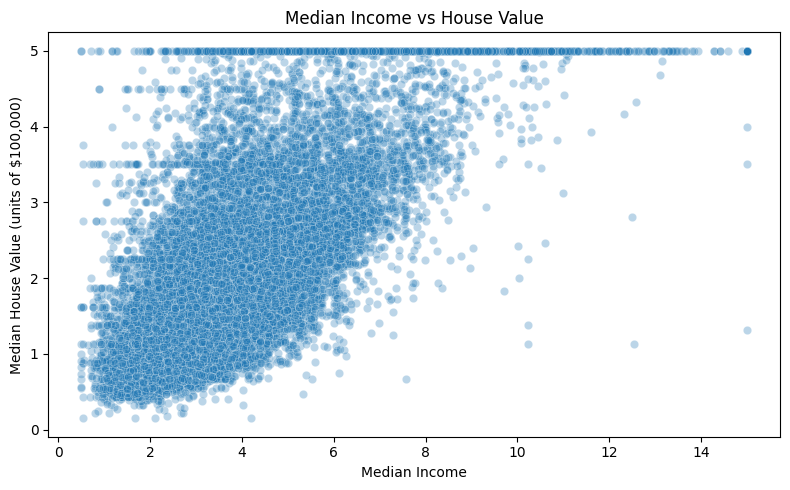

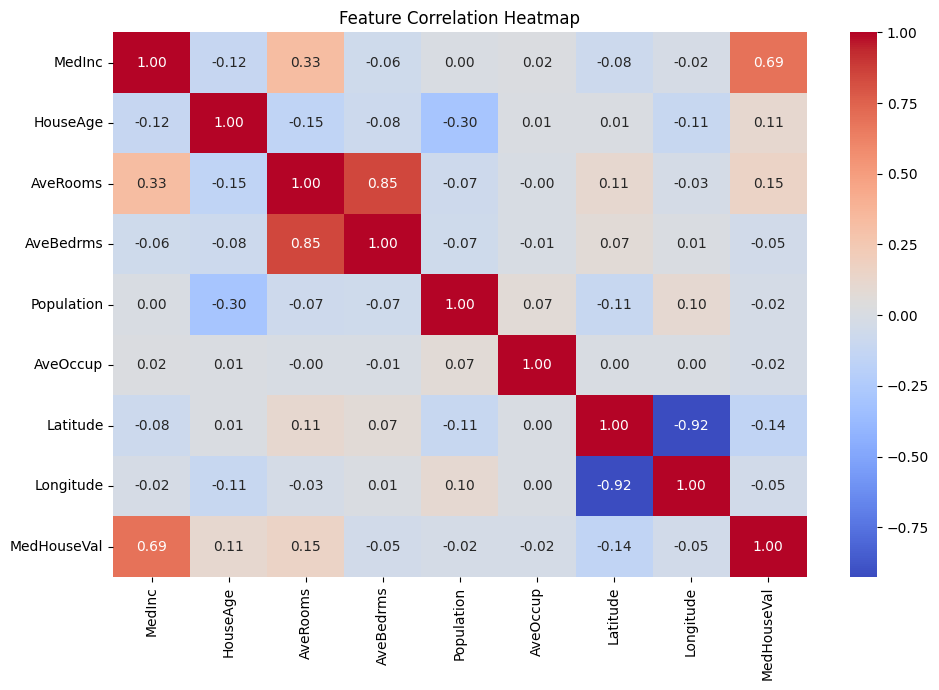


MODEL EVALUATION
Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R-squared (R2): 0.5758


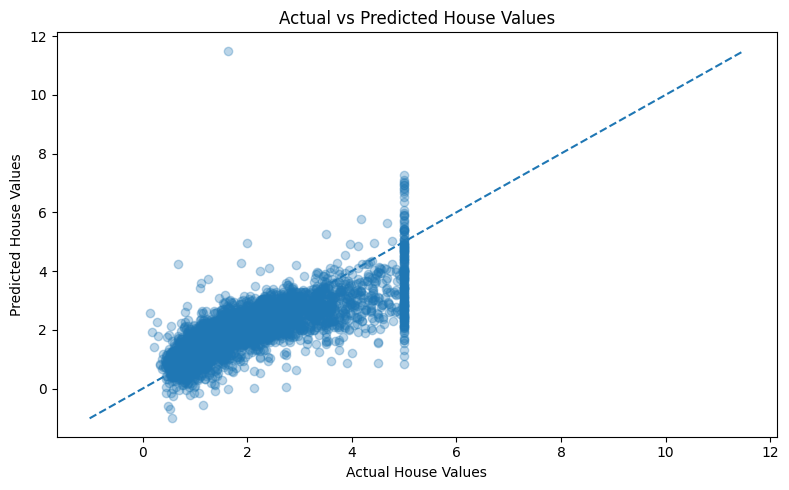


EXAMPLE PREDICTION
Predicted median house value: $ 71912.28

Project analysis completed.


In [ ]:

# HOUSE PRICE PREDICTION USING MACHINE LEARNING
# Project by Sakshi Tripathi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("HOUSE PRICE PREDICTION PROJECT")
print("=" * 40)

# 1. Inspect the dataset
print("\nDataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
print(df.describe())

# 2. Exploratory Data Analysis
plt.figure(figsize=(8, 5))
sns.histplot(df["MedHouseVal"], bins=40, kde=True)
plt.title("Distribution of House Values")
plt.xlabel("Median House Value (units of $100,000)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="MedInc", y="MedHouseVal", alpha=0.3)
plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value (units of $100,000)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3. Prepare data
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )


# 4. Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make predictions
y_pred = model.predict(X_test)

# 6. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMODEL EVALUATION")
print("=" * 40)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# 7. Actual vs Predicted visualization
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted House Values")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "--")
plt.tight_layout()
plt.show()

# 8. Example prediction for one house
sample_house = X_test.iloc[[0]]
prediction = model.predict(sample_house)[0]

print("\nEXAMPLE PREDICTION")
print("Predicted median house value: $", round(prediction * 100000, 2))
print("\nProject analysis completed.")